In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [27]:
from faker import Faker
import random
import pandas as pd

faker = Faker()

data = []

course = [
    "Python",
    "Data Science",
    "Machine Learning",
    "SQL",
    "Deep Learning",
    "Cloud Computing"
]

for _ in range(300):
    data.append({
        'student_id': faker.uuid4(),
        'course_name': random.choice(course),
        'progress_percent': random.randint(50, 100),
        'completion_days': random.randint(30, 60),
        'rating': round(random.uniform(3, 4.5), 2)
    })

df = pd.DataFrame(data)
df.to_csv("online_course.csv")

print(df.head())

                             student_id       course_name  progress_percent  \
0  025cf4f2-ccb3-4a5b-928e-1c8fadddadd8  Machine Learning                66   
1  b088a268-25c8-4db5-9aaa-9196d424571c               SQL                91   
2  c6279af3-d459-434a-8c17-d17e77d95d63               SQL                76   
3  6a5a1dd7-5fea-487b-a850-9aba21a8a0dd               SQL                98   
4  f89d0729-6157-4aaf-bcb0-065bf5aa1be5      Data Science                85   

   completion_days  rating  
0               36    4.34  
1               59    3.25  
2               58    3.64  
3               41    4.15  
4               57    3.58  


In [28]:
course_avg_progress = df.groupby('course_name')['progress_percent'].mean()

poor_courses = course_avg_progress[course_avg_progress < 70]

print(poor_courses)

Series([], Name: progress_percent, dtype: float64)


In [29]:
avg_completion_time = df.groupby('course_name')['completion_days'].mean()

print(avg_completion_time)

course_name
Cloud Computing     43.777778
Data Science        43.877193
Deep Learning       46.822222
Machine Learning    45.263158
Python              44.906977
SQL                 45.204545
Name: completion_days, dtype: float64


In [30]:
mean_days = np.mean(df['completion_days'])
median_days = np.median(df['completion_days'])
std_days = np.std(df['completion_days'])

print("Mean:", mean_days)
print("Median:", median_days)
print("Standard Deviation:", std_days)

Mean: 44.906666666666666
Median: 45.0
Standard Deviation: 8.96946424759522


In [31]:
df['improved_progress'] = np.minimum(df['progress_percent'] + 10, 100)

new_avg = df.groupby('course_name')['improved_progress'].mean()

print(new_avg)

course_name
Cloud Computing     83.759259
Data Science        88.403509
Deep Learning       84.266667
Machine Learning    82.754386
Python              82.139535
SQL                 85.545455
Name: improved_progress, dtype: float64


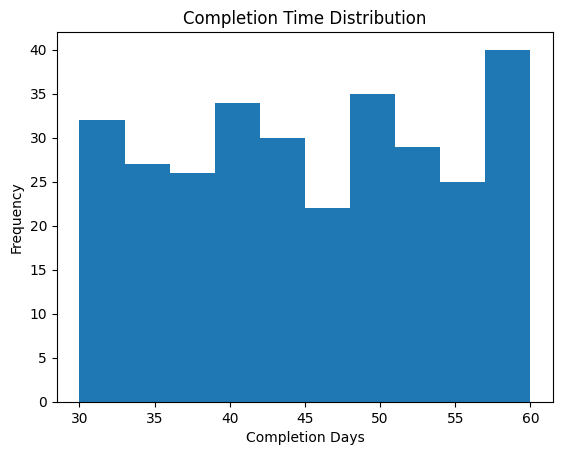

In [32]:

plt.figure()
plt.hist(df['completion_days'], bins=10)

plt.title("Completion Time Distribution")
plt.xlabel("Completion Days")
plt.ylabel("Frequency")
plt.show()

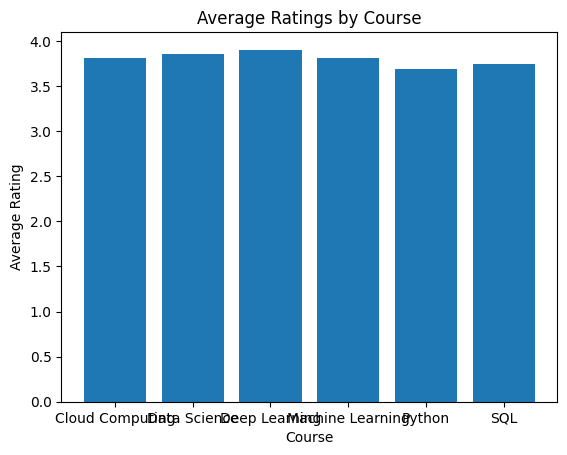

In [33]:
avg_ratings = df.groupby('course_name')['rating'].mean()

plt.figure()
plt.bar(avg_ratings.index, avg_ratings.values)

plt.title("Average Ratings by Course")
plt.xlabel("Course")
plt.ylabel("Average Rating")
plt.show()